# LiDAR Sweep Aggregation

Aggregates **5 LiDAR sweeps** around a chosen anchor frame:
2 sweeps before + anchor sweep + 2 sweeps after.

All sweeps are **ego-motion compensated**: each point cloud is transformed
to the **anchor ego frame** via the global (map) coordinate system,
so the origin stays fixed even though the vehicle was moving.

Outputs:
- **§4** — BEV plot (matplotlib, one colour per sweep)
- **§5** — Interactive 3D plot (plotly)
- **§6** — Reprojection onto the anchor camera image

## 0. Imports

In [440]:
from itertools import zip_longest
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

import plotly.graph_objects as go

from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes

## 1. Config

Change `DATASET` to switch between **`'nuscenes_mini'`** and **`'ecp'`**.

`N_BEFORE` / `N_AFTER` control how many extra sweeps are taken on each side
(default 2 each → 5 sweeps total).

In [441]:
# ══════════════════════════════════════════════════════════════════════════════
# Dataset selector  →  change this one variable to switch datasets
# ══════════════════════════════════════════════════════════════════════════════
DATASET = 'nuscenes_mini'           # 'ecp'  or  'nuscenes_mini'

if DATASET == 'nuscenes_mini':
    DATA_ROOT    = '/workspace/data/nuScenes_mini'
    NUSCENES_VER = 'v1.0-mini'
    SCENE_IDX    = 3
    FRAME_IDX    = 60      # keyframe index within the scene
elif DATASET == 'ecp':
    DATA_ROOT    = '/workspace/data/ecp'
    NUSCENES_VER = 'v1.0-trainval'
    SCENE_IDX    = 10
    FRAME_IDX    = 570    # sample_data index for ECP (walk from first_sample_token)
else:
    raise ValueError(f'Unknown DATASET: {DATASET!r}')

CAMERA   = 'CAM_FRONT'
N_BEFORE = 10    # sweeps to include before anchor
N_AFTER  = 10    # sweeps to include after anchor

# ── Ego-body filter ──────────────────────────────────────────────────────────
USE_EGO_BODY_FILTER = True    # remove ego-vehicle roof/windshield returns per sweep
EGO_BOX_HALF_X      = 4.0    # half-length fore/aft [m]
EGO_BOX_HALF_Y      = 1.5    # half-width left/right [m]
EGO_BOX_Z_MIN       = 0.5    # lower Z cutoff [m]
EGO_BOX_Z_MAX       = 2.5    # upper Z cutoff [m]

print(f'Dataset : {DATASET}')
print(f'Scene   : {SCENE_IDX}  |  Frame: {FRAME_IDX}  |  Camera: {CAMERA}')
print(f'Sweeps  : {N_BEFORE} before + 1 anchor + {N_AFTER} after  =  {N_BEFORE + 1 + N_AFTER} total')

Dataset : nuscenes_mini
Scene   : 3  |  Frame: 60  |  Camera: CAM_FRONT
Sweeps  : 10 before + 1 anchor + 10 after  =  21 total


## 2. NuScenes Setup & Anchor Frame

Scene name: scene-0655
Camera SD  : 88d46eb8858d4f2bb13c40d03196e22d
Image      : /workspace/data/nuScenes_mini/sweeps/CAM_FRONT/n008-2018-08-27-11-48-51-0400__CAM_FRONT__1535385097162404.jpg
Resolution : 1600×900  |  fx=1252.8  fy=1252.8  cx=826.6  cy=470.0


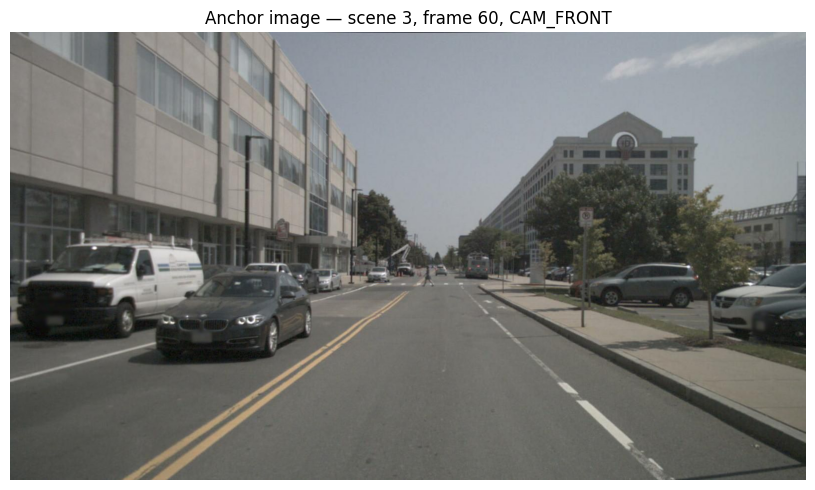

In [442]:
nusc   = NuScenes(version=NUSCENES_VER, dataroot=DATA_ROOT, verbose=False)
scene  = nusc.scene[SCENE_IDX]
print(f'Scene name: {scene["name"]}')

# ── Walk to the requested frame ───────────────────────────────────────────────
# For both datasets we follow the camera sample_data linked list, then look up
# the synchronised LIDAR_TOP sweep.
cam_sd_token = nusc.get('sample', scene['first_sample_token'])['data'][CAMERA]
for _ in range(FRAME_IDX):
    sd = nusc.get('sample_data', cam_sd_token)
    if not sd['next']:
        raise ValueError(f'FRAME_IDX={FRAME_IDX} exceeds scene length.')
    cam_sd_token = sd['next']

cam_sd   = nusc.get('sample_data', cam_sd_token)
img_path = nusc.get_sample_data_path(cam_sd_token)
cam_cal  = nusc.get('calibrated_sensor', cam_sd['calibrated_sensor_token'])
cam_ep   = nusc.get('ego_pose', cam_sd['ego_pose_token'])

K     = np.array(cam_cal['camera_intrinsic'], dtype=np.float64)
R_c2e = Quaternion(cam_cal['rotation']).rotation_matrix.astype(np.float64)
t_c2e = np.array(cam_cal['translation'], dtype=np.float64)
fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]

# Anchor ego → global transform (used for ego-motion compensation reference)
R_e2g_anchor = Quaternion(cam_ep['rotation']).rotation_matrix.astype(np.float64)
t_e2g_anchor = np.array(cam_ep['translation'], dtype=np.float64)

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

print(f'Camera SD  : {cam_sd_token}')
print(f'Image      : {img_path}')
print(f'Resolution : {W}×{H}  |  fx={fx:.1f}  fy={fy:.1f}  cx={cx:.1f}  cy={cy:.1f}')

plt.figure(figsize=(14, 5))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Anchor image — scene {SCENE_IDX}, frame {FRAME_IDX}, {CAMERA}')
plt.tight_layout()
plt.show()

## 3. Collect ±N LiDAR Sweeps

Finds the LiDAR sweep closest in time to the anchor camera frame, then walks
the `prev` / `next` linked list to gather `N_BEFORE` earlier and `N_AFTER` later sweeps.

Each sweep record stores its own **ego_pose** (the vehicle pose at capture time),
which is used for ego-motion compensation in §3.1.

In [443]:
# ── Find anchor LiDAR sweep ────────────────────────────────────────────────────
cam_ts = cam_sd['timestamp']

if cam_sd['is_key_frame']:
    _sample    = nusc.get('sample', cam_sd['sample_token'])
    anchor_lid_token = _sample['data']['LIDAR_TOP']
else:
    anchor_lid_token = min(
        (sd for sd in nusc.sample_data if sd['channel'] == 'LIDAR_TOP'),
        key=lambda sd: abs(sd['timestamp'] - cam_ts),
    )['token']

print(f'Anchor LiDAR token: {anchor_lid_token}')

# ── Walk linked list, skipping duplicate file entries ─────────────────────────
def _walk_lidar_tokens(nusc, anchor_token, n_before, n_after):
    """
    Return ordered list of (relative_index, lidar_sd_token) with exactly
    n_before unique sweeps before and n_after unique sweeps after the anchor
    (or fewer if the scene boundary is reached first).

    Duplicate file entries — a known ECP→nuScenes conversion artefact where
    multiple tokens point to the same .bin — are silently skipped so they
    never consume a slot.
    """
    anchor_path = nusc.get_sample_data_path(anchor_token)
    seen_paths  = {anchor_path}

    # Walk backward: keep going until n_before unique files are found
    backward = []
    tok = nusc.get('sample_data', anchor_token)['prev']
    while tok and len(backward) < n_before:
        path = nusc.get_sample_data_path(tok)
        if path not in seen_paths:
            backward.append(tok)
            seen_paths.add(path)
        tok = nusc.get('sample_data', tok)['prev']

    tokens = []
    for i, t in enumerate(reversed(backward)):
        tokens.append((-(len(backward) - i), t))

    tokens.append((0, anchor_token))

    # Walk forward: keep going until n_after unique files are found
    count = 0
    tok   = nusc.get('sample_data', anchor_token)['next']
    while tok and count < n_after:
        path = nusc.get_sample_data_path(tok)
        if path not in seen_paths:
            count += 1
            tokens.append((count, tok))
            seen_paths.add(path)
        tok = nusc.get('sample_data', tok)['next']

    return tokens


sweep_tokens = _walk_lidar_tokens(nusc, anchor_lid_token, N_BEFORE, N_AFTER)

print(f'\nCollected {len(sweep_tokens)} sweep(s):')
print(f'{"idx":>4}  {"dt [ms]":>10}  {"filename"}')
for rel_idx, tok in sweep_tokens:
    sd    = nusc.get('sample_data', tok)
    dt    = (sd['timestamp'] - cam_ts) / 1000.0
    fname = Path(nusc.get_sample_data_path(tok)).name
    tag   = '  ← anchor' if rel_idx == 0 else ''
    print(f'{rel_idx:+4d}  {dt:+10.1f} ms  {fname}{tag}')


Anchor LiDAR token: a7b12a06ed6642b38d5876a40ae396f2

Collected 21 sweep(s):
 idx     dt [ms]  filename
 -10      -512.2 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096650175.pcd.bin
  -9      -462.4 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096700021.pcd.bin
  -8      -412.1 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096750254.pcd.bin
  -7      -362.4 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096800031.pcd.bin
  -6      -312.1 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096850352.pcd.bin
  -5      -262.3 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096900138.pcd.bin
  -4      -212.0 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096950435.pcd.bin
  -3      -162.2 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385097000206.pcd.bin
  -2      -111.9 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385097050531.pcd.bin
  -1       -62.1 ms  n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385097100330.pcd.bin
  +0       -12.3

## 3.1 Load & Ego-Motion Compensate All Sweeps

Each LiDAR point is transformed to the **anchor ego frame** via:

```
p_lidar  →  p_ego_sweep  =  R_l2e @ p_lidar + t_l2e
p_global =  R_e2g_sweep  @ p_ego_sweep + t_e2g_sweep
p_ego_anchor = R_e2g_anchor.T @ (p_global - t_e2g_anchor)
```

where `R_e2g_anchor` / `t_e2g_anchor` are taken from the **camera** ego_pose at the
anchor timestamp (same vehicle, sub-millisecond difference).

In [444]:
sweep_data = []   # list of dicts, one per sweep (all unique — dedup done in walk)

for rel_idx, tok in sweep_tokens:
    sd       = nusc.get('sample_data', tok)
    lid_path = nusc.get_sample_data_path(tok)
    lid_cal  = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    ego_pose = nusc.get('ego_pose', sd['ego_pose_token'])

    R_l2e    = Quaternion(lid_cal['rotation']).rotation_matrix.astype(np.float64)
    t_l2e    = np.array(lid_cal['translation'], dtype=np.float64)
    R_e2g_sw = Quaternion(ego_pose['rotation']).rotation_matrix.astype(np.float64)
    t_e2g_sw = np.array(ego_pose['translation'], dtype=np.float64)

    pts_raw     = np.fromfile(lid_path, dtype=np.float32).reshape(-1, 5)[:, :3].astype(np.float64)

    # LiDAR → ego (at sweep time) → (ego-body filter) → global → anchor ego
    pts_ego_sw  = (R_l2e @ pts_raw.T).T + t_l2e
    # ── Ego-body filter in sweep's own ego frame (vehicle always at origin) ──
    if USE_EGO_BODY_FILTER:
        _sw_box = (
            (np.abs(pts_ego_sw[:, 0]) < EGO_BOX_HALF_X) &
            (np.abs(pts_ego_sw[:, 1]) < EGO_BOX_HALF_Y) &
            (pts_ego_sw[:, 2] > EGO_BOX_Z_MIN) &
            (pts_ego_sw[:, 2] < EGO_BOX_Z_MAX)
        )
        pts_ego_sw = pts_ego_sw[~_sw_box]
    pts_global  = (R_e2g_sw @ pts_ego_sw.T).T + t_e2g_sw
    pts_ego_anc = (R_e2g_anchor.T @ (pts_global - t_e2g_anchor).T).T

    dt_ms = (sd['timestamp'] - cam_ts) / 1000.0
    sweep_data.append({
        'rel_idx':     rel_idx,
        'token':       tok,
        'dt_ms':       dt_ms,
        'pts_ego_anc': pts_ego_anc.astype(np.float32),
        'n_pts':       len(pts_ego_anc),
    })
    print(f'  [{rel_idx:+d}]  {len(pts_ego_anc):6,} pts  dt={dt_ms:+7.1f} ms   {Path(lid_path).name}')

total_pts = sum(s['n_pts'] for s in sweep_data)
print(f'\nLoaded {len(sweep_data)} sweep(s)  |  {total_pts:,} points total')


  [-10]  26,089 pts  dt= -512.2 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096650175.pcd.bin
  [-9]  26,193 pts  dt= -462.4 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096700021.pcd.bin
  [-8]  26,099 pts  dt= -412.1 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096750254.pcd.bin
  [-7]  26,004 pts  dt= -362.4 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096800031.pcd.bin
  [-6]  26,065 pts  dt= -312.1 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096850352.pcd.bin
  [-5]  25,987 pts  dt= -262.3 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096900138.pcd.bin
  [-4]  25,971 pts  dt= -212.0 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385096950435.pcd.bin
  [-3]  26,010 pts  dt= -162.2 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385097000206.pcd.bin
  [-2]  26,038 pts  dt= -111.9 ms   n008-2018-08-27-11-48-51-0400__LIDAR_TOP__1535385097050531.pcd.bin
  [-1]  25,985 pts  dt=  -62.1 ms   n008-2018-08-27-11-48-51-0400__LIDAR

## 4. BEV Plot

Bird's-eye view of all aggregated sweeps in the anchor ego frame.
Each sweep has a distinct colour.  The ego vehicle is at the origin (gold diamond).

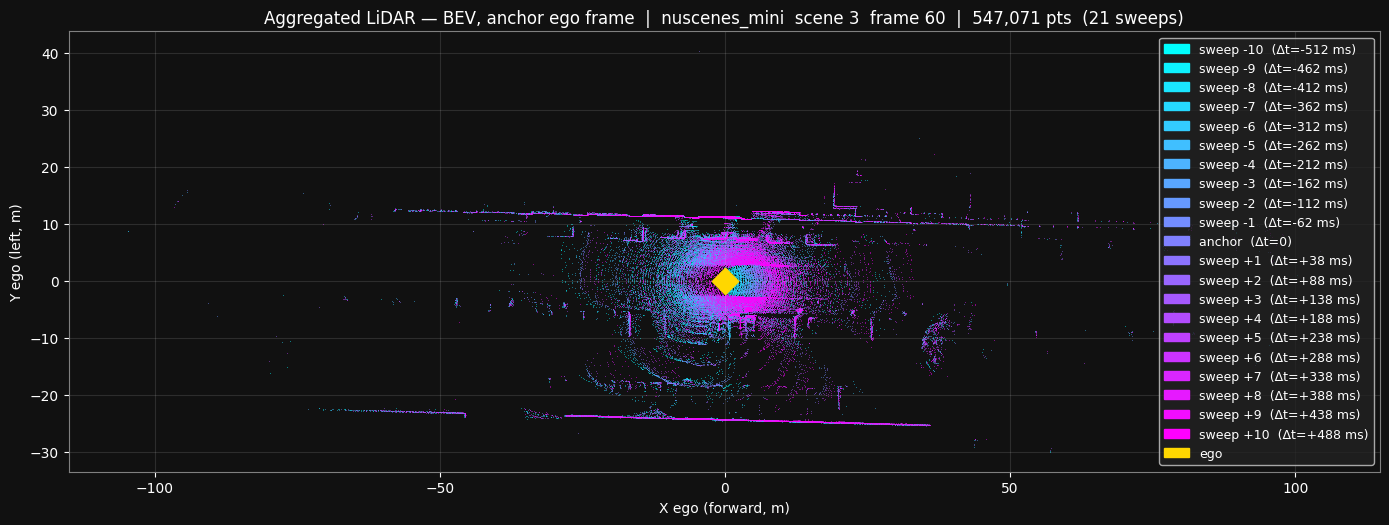

In [445]:
# Colour palette — one colour per sweep, ordered past → future
# Using a perceptually uniform sequential map so temporal ordering is visible
_cmap_bev  = plt.colormaps.get_cmap('cool').resampled(len(sweep_data))
SWEEP_COLORS = [_cmap_bev(i) for i in range(len(sweep_data))]

# ── Subsample for performance ─────────────────────────────────────────────────
MAX_PTS_BEV = 80_000   # total across all sweeps
_per_sweep  = max(1, MAX_PTS_BEV // len(sweep_data))

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#111111')
ax.set_facecolor('#111111')

legend_handles = []

for i, s in enumerate(sweep_data):
    pts   = s['pts_ego_anc']
    color = SWEEP_COLORS[i]
    step  = max(1, len(pts) // _per_sweep)
    pts_s = pts[::step]

    ax.scatter(pts_s[:, 0], pts_s[:, 1],
               s=0.3, color=color, alpha=0.6, linewidths=0, rasterized=True)

    label = ('anchor  (Δt=0)' if s['rel_idx'] == 0
             else f'sweep {s["rel_idx"]:+d}  (Δt={s["dt_ms"]:+.0f} ms)')
    legend_handles.append(mpatches.Patch(color=color, label=label))

# Ego vehicle
ax.scatter([0], [0], s=180, c='gold', marker='D', zorder=10)
legend_handles.append(mpatches.Patch(color='gold', label='ego'))

ax.set_aspect('equal')
ax.set_xlabel('X ego (forward, m)', color='white')
ax.set_ylabel('Y ego (left, m)',     color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values():
    sp.set_color('gray')
ax.set_title(
    f'Aggregated LiDAR — BEV, anchor ego frame  |  {DATASET}  '
    f'scene {SCENE_IDX}  frame {FRAME_IDX}  |  {total_pts:,} pts  '
    f'({len(sweep_data)} sweeps)',
    color='white',
)
ax.legend(handles=legend_handles, loc='upper right',
          facecolor='#222222', labelcolor='white', fontsize=9)
ax.grid(True, alpha=0.12, color='white')
plt.tight_layout()
plt.show()


## 5. Interactive 3D Plot (Plotly)

Same data as the BEV, but with the Z dimension (height) included.
Points are coloured by sweep index (past → future) and can be toggled in the legend.

In [446]:
# RGB strings for plotly, same palette as the BEV
def _rgba_to_rgb_str(c):
    r, g, b = int(c[0]*255), int(c[1]*255), int(c[2]*255)
    return f'rgb({r},{g},{b})'

SWEEP_COLORS_PL = [_rgba_to_rgb_str(SWEEP_COLORS[i]) for i in range(len(sweep_data))]

MAX_PTS_3D  = 60_000
_per_sw_3d  = max(1, MAX_PTS_3D // len(sweep_data))
RADIUS_3D   = 55.0   # metres — horizontal (XY) radius around ego
X_MIN_3D    = -5.0   # metres — drop points more than 5 m behind ego (X ego = forward)

traces = []

for i, s in enumerate(sweep_data):
    pts  = s['pts_ego_anc']
    r_xy = np.sqrt(pts[:, 0]**2 + pts[:, 1]**2)
    pts  = pts[(r_xy <= RADIUS_3D) & (pts[:, 0] >= X_MIN_3D)]

    color = SWEEP_COLORS_PL[i]
    step  = max(1, len(pts) // _per_sw_3d)
    pts_s = pts[::step]

    label = ('anchor  (Δt=0)' if s['rel_idx'] == 0
             else f'sweep {s["rel_idx"]:+d}  (Δt={s["dt_ms"]:+.0f} ms)')

    traces.append(go.Scatter3d(
        x=pts_s[:, 0], y=pts_s[:, 1], z=pts_s[:, 2],
        mode='markers',
        marker=dict(size=1.5, color=color, opacity=0.65),
        name=label,
        legendgroup=label,
    ))

# Ego marker
traces.append(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=7, color='gold', symbol='diamond'),
    name='ego',
))

fig3d = go.Figure(data=traces)
fig3d.update_layout(
    title=(f'Aggregated LiDAR — 3D, anchor ego frame  |  {DATASET}  '
           f'scene {SCENE_IDX}  frame {FRAME_IDX}  |  {total_pts:,} pts  '
           f'|  r ≤ {RADIUS_3D:.0f} m  |  x ≥ {X_MIN_3D:.0f} m'),
    scene=dict(
        xaxis_title='X ego (forward, m)',
        yaxis_title='Y ego (left, m)',
        zaxis_title='Z ego (up, m)',
        aspectmode='data',
        bgcolor='rgb(15,15,25)',
        xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white',
                   range=[X_MIN_3D, RADIUS_3D]),
        yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white',
                   range=[-RADIUS_3D, RADIUS_3D]),
        zaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    ),
    paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.55)', font=dict(size=10)),
    width=1100, height=650, margin=dict(l=0, r=0, t=45, b=0),
)
fig3d.show()


## 6. Reprojection onto Anchor Camera Image

All aggregated ego-frame points are projected into the anchor camera frame:

```
p_cam = R_c2e.T @ (p_ego_anchor − t_c2e)
u = p_cam.x / p_cam.z * fx + cx
v = p_cam.y / p_cam.z * fy + cy
```

Points are coloured by **depth** (metres).  Toggle `COLOR_BY` to switch between
depth-based colouring and per-sweep colouring.

Visible points in CAM_FRONT: 64,640  (depth 4.4–103.8 m)


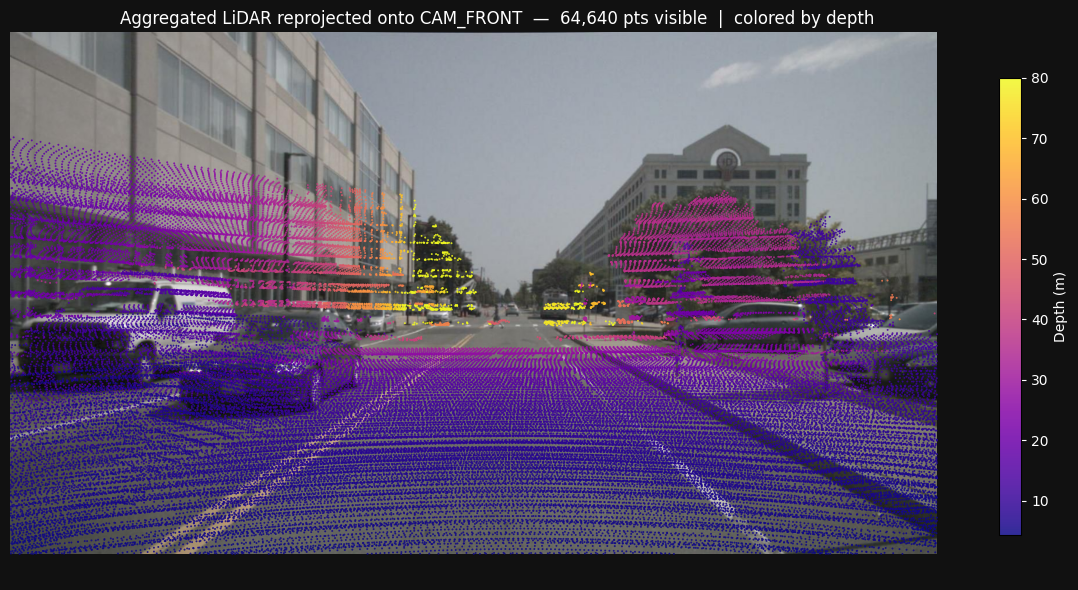

In [447]:
COLOR_BY = 'depth'   # 'depth'  or  'sweep'

# ── Concatenate all sweeps, tagging each point with its sweep index (0-based) ─
all_pts    = np.concatenate([s['pts_ego_anc'] for s in sweep_data], axis=0)
all_sw_idx = np.concatenate([
    np.full(s['n_pts'], i, dtype=np.int32)
    for i, s in enumerate(sweep_data)
], axis=0)

# ── Project to camera frame ───────────────────────────────────────────────────
pts_cam = (R_c2e.T @ (all_pts.astype(np.float64) - t_c2e).T).T   # (N, 3)  R3 camera

front  = pts_cam[:, 2] > 0
u_all  = pts_cam[front, 0] / pts_cam[front, 2] * fx + cx
v_all  = pts_cam[front, 1] / pts_cam[front, 2] * fy + cy
Z_all  = pts_cam[front, 2].astype(np.float32)
sw_all = all_sw_idx[front]

in_img = (u_all >= 0) & (u_all < W) & (v_all >= 0) & (v_all < H)
u_vis  = u_all[in_img].astype(np.float32)
v_vis  = v_all[in_img].astype(np.float32)
Z_vis  = Z_all[in_img]
sw_vis = sw_all[in_img]

print(f'Visible points in {CAMERA}: {len(u_vis):,}  '
      f'(depth {Z_vis.min():.1f}–{Z_vis.max():.1f} m)')

# ── Render ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6), facecolor='#111111')
ax.set_facecolor('#111111')
ax.imshow(img_rgb)

if COLOR_BY == 'depth':
    sc = ax.scatter(
        u_vis, v_vis,
        c=Z_vis, cmap='plasma',
        norm=plt.Normalize(vmin=Z_vis.min(), vmax=min(Z_vis.max(), 80.0)),
        s=2, linewidths=0, alpha=0.85,
    )
    cbar = fig.colorbar(sc, ax=ax, fraction=0.015, pad=0.01)
    cbar.set_label('Depth (m)', color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

elif COLOR_BY == 'sweep':
    legend_handles = []
    for i, s in enumerate(sweep_data):
        mask  = sw_vis == i
        color = SWEEP_COLORS[i]
        ax.scatter(u_vis[mask], v_vis[mask],
                   s=2, color=color, alpha=0.75, linewidths=0, rasterized=True)
        label = ('anchor  (Δt=0)' if s['rel_idx'] == 0
                 else f'sweep {s["rel_idx"]:+d}  (Δt={s["dt_ms"]:+.0f} ms)')
        legend_handles.append(mpatches.Patch(color=color, label=label))
    ax.legend(handles=legend_handles, loc='upper right',
              facecolor='#222222', labelcolor='white', fontsize=9)

ax.axis('off')
ax.set_title(
    f'Aggregated LiDAR reprojected onto {CAMERA}  —  {len(u_vis):,} pts visible  '
    f'|  colored by {COLOR_BY}',
    color='white',
)
fig.patch.set_facecolor('#111111')
plt.tight_layout()
plt.show()


## 7. SAM3 Segmentation on Anchor Frame

Runs **SAM3** with class prompts `car`, `bicycle`, `motorcycle`, `pedestrian` on the anchor image.
Results are **cached per scene/frame** to `/workspace/cache/sam3/sam3_icp/`
so you can re-run later cells without re-running inference.

Each detected instance becomes a numbered mask used downstream for motion estimation.

Loading SAM3 masks from cache: /workspace/cache/sam3/sam3_icp/nuscenes_mini_scene3_frame60_CAM_FRONT.pkl
  15 mask(s) loaded.
Total masks: 15


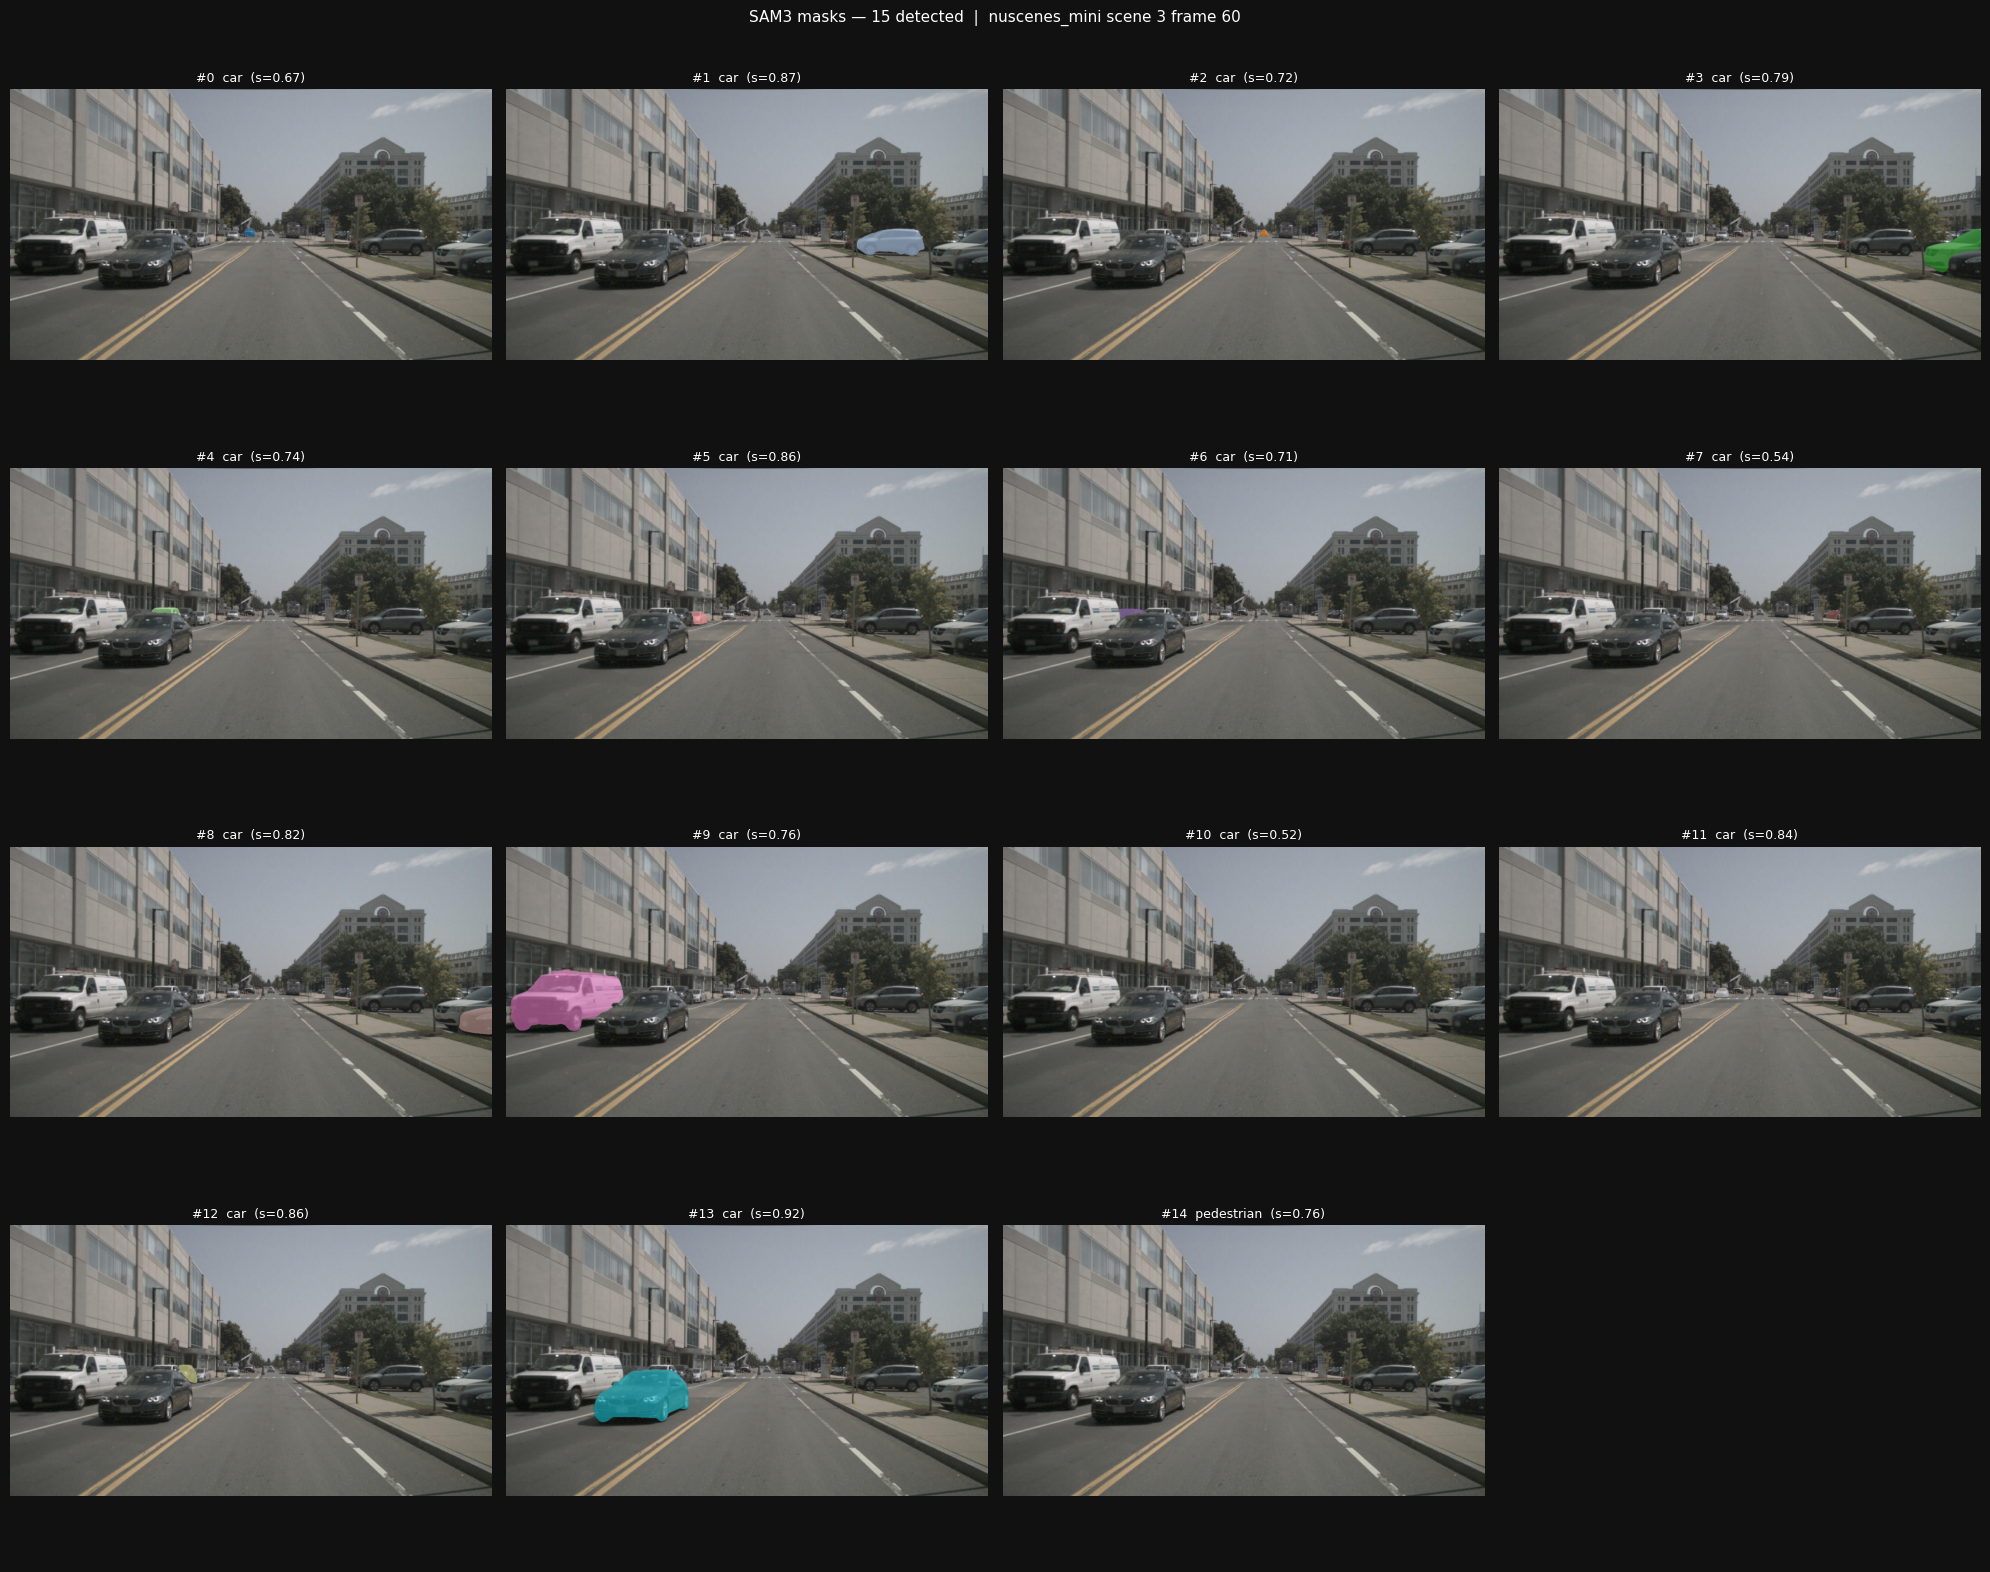

In [448]:
import os, gc, shutil, tempfile, pickle
import torch
from PIL import Image as _PILImage

SAM3_CKPT = '/workspace/models/SAM3/checkpoints/sam3.pt'
SAM3_PROMPTS       = ['car', 'bicycle', 'motorcycle', 'pedestrian']
SAM3_SCORE_THRESH  = 0.5
SAM3_MIN_MASK_PX   = 100

# ── Cache ─────────────────────────────────────────────────────────────────────
_SAM3_CACHE_DIR = Path('/workspace/cache/sam3/sam3_icp')
_SAM3_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_cache_path = _SAM3_CACHE_DIR / f'{DATASET}_scene{SCENE_IDX}_frame{FRAME_IDX}_{CAMERA}.pkl'


def _run_sam3_single_frame(img_rgb, prompt, predictor):
    tmp_dir = tempfile.mkdtemp(prefix='sam3_lidar_')
    try:
        _PILImage.fromarray(img_rgb).save(os.path.join(tmp_dir, '00000.jpg'))
        resp       = predictor.handle_request(dict(type='start_session', resource_path=tmp_dir))
        session_id = resp['session_id']
        predictor.handle_request(dict(
            type='add_prompt', session_id=session_id, frame_index=0, text=prompt
        ))
        frame_outputs = {}
        with torch.autocast('cuda', dtype=torch.bfloat16):
            for r in predictor.handle_stream_request(dict(
                type='propagate_in_video', session_id=session_id
            )):
                frame_outputs[r['frame_index']] = r['outputs']
        predictor.handle_request(dict(type='close_session', session_id=session_id))
    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)

    out     = frame_outputs.get(0, {})
    obj_ids = out.get('out_obj_ids', [])
    probs   = np.asarray(out.get('out_probs', []), dtype=np.float32)
    masks   = out.get('out_binary_masks', [])
    dets    = []
    for i, (_, prob) in enumerate(zip(obj_ids, probs)):
        if prob < SAM3_SCORE_THRESH:
            continue
        bm = np.asarray(masks[i], dtype=bool)
        if bm.sum() < SAM3_MIN_MASK_PX:
            continue
        dets.append({'binary_mask': bm, 'score': float(prob), 'prompt': prompt})
    return dets


# ── Load from cache or run inference ──────────────────────────────────────────
if _cache_path.exists():
    print(f'Loading SAM3 masks from cache: {_cache_path}')
    with open(_cache_path, 'rb') as _f:
        sam3_masks = pickle.load(_f)
    print(f'  {len(sam3_masks)} mask(s) loaded.')
else:
    print('Running SAM3...')
    from sam3.model_builder import build_sam3_video_predictor
    _gpus      = list(range(torch.cuda.device_count()))
    _predictor = build_sam3_video_predictor(gpus_to_use=_gpus, checkpoint_path=SAM3_CKPT)

    sam3_masks = []
    for _prompt in SAM3_PROMPTS:
        print(f'  Prompt: {_prompt!r}')
        _dets = _run_sam3_single_frame(img_rgb, _prompt, _predictor)
        sam3_masks.extend(_dets)
        print(f'    → {len(_dets)} detection(s)')

    del _predictor; gc.collect(); torch.cuda.empty_cache()

    with open(_cache_path, 'wb') as _f:
        pickle.dump(sam3_masks, _f)
    print(f'Cached to {_cache_path}')

print(f'Total masks: {len(sam3_masks)}')

# ── Visualise all masks ───────────────────────────────────────────────────────
MASK_COLORS = plt.colormaps['tab20'].resampled(max(len(sam3_masks), 1))

_ncols  = min(4, max(1, len(sam3_masks)))
_nrows  = max(1, (len(sam3_masks) + _ncols - 1) // _ncols)
_fig_s, _axes_s = plt.subplots(_nrows, _ncols,
                                figsize=(5 * _ncols, 4 * _nrows),
                                facecolor='#111111')
_axes_flat = np.array(_axes_s).flatten()

for _ai, (_mi, _ax) in enumerate(zip(sam3_masks, _axes_flat)):
    _ov    = img_rgb.copy()
    _cr    = MASK_COLORS(_ai)
    _col   = np.array([int(_cr[0]*255), int(_cr[1]*255), int(_cr[2]*255)])
    _m2d   = _mi['binary_mask']
    _ov[_m2d] = (_ov[_m2d] * 0.4 + _col * 0.6).astype(np.uint8)
    _ax.imshow(_ov)
    _ax.set_title(f'#{_ai}  {_mi["prompt"]}  (s={_mi["score"]:.2f})',
                  color='white', fontsize=9)
    _ax.axis('off')
    _ax.set_facecolor('#111111')
for _ax in _axes_flat[len(sam3_masks):]:
    _ax.axis('off')

_fig_s.patch.set_facecolor('#111111')
plt.suptitle(
    f'SAM3 masks — {len(sam3_masks)} detected  |  {DATASET} scene {SCENE_IDX} frame {FRAME_IDX}',
    color='white', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Project All Sweeps into Camera Space

For each LiDAR sweep, every ego-frame point is projected into the anchor camera image.
The resulting `(u, v)` arrays are stored parallel to `sweep_data` so downstream code
can efficiently look up which 3D points fall inside any SAM3 mask pixel-by-pixel.

A convenience function `get_mask_pts_3d(mask_idx, sweep_idx)` is also defined here.

In [449]:
# sweep_uv[i] — (N_pts, 2) float32; u=-1 means the point is off-screen
sweep_uv = []

for _s in sweep_data:
    _pts    = _s['pts_ego_anc'].astype(np.float64)          # (N,3) anchor ego frame
    _p_cam  = (R_c2e.T @ (_pts - t_c2e).T).T               # (N,3) camera frame

    _valid  = _p_cam[:, 2] > 0.1
    _u = np.full(len(_pts), -1.0, np.float32)
    _v = np.full(len(_pts), -1.0, np.float32)

    _u_r = _p_cam[_valid, 0] / _p_cam[_valid, 2] * fx + cx
    _v_r = _p_cam[_valid, 1] / _p_cam[_valid, 2] * fy + cy
    _in  = (_u_r >= 0) & (_u_r < W) & (_v_r >= 0) & (_v_r < H)

    _vi = np.where(_valid)[0]
    _u[_vi[_in]] = _u_r[_in]
    _v[_vi[_in]] = _v_r[_in]
    sweep_uv.append(np.stack([_u, _v], axis=1))

print(f'Projected {len(sweep_data)} sweeps into camera space.')
_anchor_i_check = next(i for i, s in enumerate(sweep_data) if s['rel_idx'] == 0)
print(f'Anchor sweep: {(sweep_uv[_anchor_i_check][:, 0] >= 0).sum():,} in-image '
      f'/ {len(sweep_uv[_anchor_i_check]):,} total points')


def get_mask_pts_3d(mask_idx: int, sweep_idx: int) -> np.ndarray:
    """Return (M, 3) ego-frame points inside `mask_idx` from `sweep_idx`."""
    mask2d = sam3_masks[mask_idx]['binary_mask']   # (H, W) bool
    uv     = sweep_uv[sweep_idx]                   # (N, 2)
    in_fr  = uv[:, 0] >= 0
    ui     = uv[in_fr, 0].astype(np.int32)
    vi     = uv[in_fr, 1].astype(np.int32)
    in_mk  = mask2d[vi, ui]
    return sweep_data[sweep_idx]['pts_ego_anc'][np.where(in_fr)[0][in_mk]]

Projected 21 sweeps into camera space.
Anchor sweep: 2,601 in-image / 26,019 total points


## 8.5  Ground Segmentation — TerraSeg

**TerraSeg-S** (PointTransformerV3 backbone, trained on OmniLiDAR) assigns every
LiDAR point a binary label: **0 = ground, 1 = non-ground**.

Running on the **full sweep** (not the ROI crop) gives the model full spatial context —
consistent with how it was trained.  The resulting `sweep_nonground_pts[i]` lists are
used by §9 instead of PseudoLabeler so the ROI crops are already ground-free before HDBSCAN.

The 3D plot below shows the anchor sweep coloured by label.

In [450]:
import sys, torch

_TS_LIB  = '/workspace/models/TerraSeg/terraseg_lib/src'
_PTV3_LIB = '/workspace/models/TerraSeg/ptv3/src'
_TS_CKPT  = '/workspace/models/TerraSeg/checkpoints/terraseg_s.pth'

for _p in [_TS_LIB, _PTV3_LIB]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from terraseg.predictor import TerraSegPredictor

print('Loading TerraSeg-S...', end=' ', flush=True)
terraseg_predictor = TerraSegPredictor(variant='S', checkpoint_path=_TS_CKPT)
print('done.')

# ── Run on every sweep (full sweep for accurate spatial context) ───────────────
_ts_ground_masks   = []   # per sweep: bool array, True = non-ground
sweep_nonground_pts = []  # per sweep: (M, 3) pts with ground removed

for _i, _s in enumerate(sweep_data):
    _pts = _s['pts_ego_anc']
    with torch.no_grad():
        _lbl = terraseg_predictor.predict(
            torch.tensor(_pts.copy(), dtype=torch.float32).contiguous()
        ).cpu().numpy()
    _is_ng = _lbl == 1   # 1 = non-ground
    _ts_ground_masks.append(_is_ng)
    sweep_nonground_pts.append(_pts[_is_ng])
    print(f'  sweep {_s["rel_idx"]:+d}:  '
          f'{_is_ng.sum():6,} / {len(_pts):6,} non-ground  '
          f'({100 * _is_ng.mean():.1f} %)')

print(f'\nDone. {len(sweep_nonground_pts)} sweeps.')

# ── 3D visualisation: anchor sweep coloured by ground label ───────────────────
_anc_i_gnd = next(i for i, s in enumerate(sweep_data) if s['rel_idx'] == 0)
_pts_anc   = sweep_data[_anc_i_gnd]['pts_ego_anc']
_is_ng_anc = _ts_ground_masks[_anc_i_gnd]

# Subsample for plotly performance
_MAX_GND_VIZ = 50_000
_step        = max(1, len(_pts_anc) // _MAX_GND_VIZ)
_pts_v       = _pts_anc[::_step]
_ng_v        = _is_ng_anc[::_step]

_gnd_pts  = _pts_v[~_ng_v]
_obj_pts  = _pts_v[ _ng_v]

_fig_gnd = go.Figure()
_fig_gnd.add_trace(go.Scatter3d(
    x=_gnd_pts[:, 0], y=_gnd_pts[:, 1], z=_gnd_pts[:, 2],
    mode='markers',
    marker=dict(size=1.5, color='tomato', opacity=0.55),
    name=f'ground ({len(_gnd_pts):,} pts sampled)',
))
_fig_gnd.add_trace(go.Scatter3d(
    x=_obj_pts[:, 0], y=_obj_pts[:, 1], z=_obj_pts[:, 2],
    mode='markers',
    marker=dict(size=1.5, color='deepskyblue', opacity=0.50),
    name=f'non-ground ({len(_obj_pts):,} pts sampled)',
))
_fig_gnd.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=8, color='gold', symbol='diamond'),
    name='ego',
))

_fig_gnd.update_layout(
    title=(f'TerraSeg-S ground segmentation — anchor sweep  |  '
           f'{DATASET}  scene {SCENE_IDX}  frame {FRAME_IDX}  |  '
           f'{len(_pts_anc):,} pts total  (subsampled 1:{_step})'),
    scene=dict(
        xaxis_title='X ego (forward, m)',
        yaxis_title='Y ego (left, m)',
        zaxis_title='Z ego (up, m)',
        aspectmode='data',
        bgcolor='rgb(15,15,25)',
        xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
        yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
        zaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    ),
    paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.55)', font=dict(size=11)),
    width=1100, height=620,
    margin=dict(l=0, r=0, t=45, b=0),
)
_fig_gnd.show()

Loading TerraSeg-S... done.
  sweep -10:  10,866 / 26,089 non-ground  (41.6 %)
  sweep -9:  10,977 / 26,193 non-ground  (41.9 %)
  sweep -8:  10,878 / 26,099 non-ground  (41.7 %)
  sweep -7:  10,855 / 26,004 non-ground  (41.7 %)
  sweep -6:  11,034 / 26,065 non-ground  (42.3 %)
  sweep -5:  10,953 / 25,987 non-ground  (42.1 %)
  sweep -4:  10,891 / 25,971 non-ground  (41.9 %)
  sweep -3:  10,897 / 26,010 non-ground  (41.9 %)
  sweep -2:  10,913 / 26,038 non-ground  (41.9 %)
  sweep -1:  10,950 / 25,985 non-ground  (42.1 %)
  sweep +0:  11,056 / 26,019 non-ground  (42.5 %)
  sweep +1:  11,094 / 26,026 non-ground  (42.6 %)
  sweep +2:  11,109 / 25,987 non-ground  (42.7 %)
  sweep +3:  11,371 / 26,080 non-ground  (43.6 %)
  sweep +4:  11,307 / 26,075 non-ground  (43.4 %)
  sweep +5:  11,318 / 26,105 non-ground  (43.4 %)
  sweep +6:  11,466 / 26,086 non-ground  (44.0 %)
  sweep +7:  11,539 / 26,085 non-ground  (44.2 %)
  sweep +8:  11,815 / 26,094 non-ground  (45.3 %)
  sweep +9:  12,085 /

## 9. Motion Classification + SE(2) ICP per Mask

For each SAM3 mask:

**Anchor sweep** — eroded 2D mask → `filter_inmask_lidar_hdbscan` (dominant cluster) → reference cluster `C₀`, centroid `c₀`.

**Non-anchor sweeps** — processed outward from anchor in both directions (+1→+N, −1→−N):
- **Propagating ROI**: search center starts at `c₀`, advances to each sweep's **dominant cluster centroid** (temporal neighbor). A validation guard (`||jump|| < class_max_speed × dt`) prevents cascade on a bad cluster pick.
- **ROI crop** of the full TerraSeg-cleaned sweep → `filter_inmask_lidar_hdbscan` → dominant cluster (same logic as anchor, not nearest-to-center)
- **Z-floor** filter removes ground stragglers below `anchor_z_min − 0.20 m`
- **SE(2) ICP** (centroid-initialized) aligns each cluster to `C₀`

**Static/dynamic classification** — `velocity = median( ||centroid_i − c₀|| / |dt_i| )` across all non-anchor sweeps that yielded a valid dominant cluster. Static objects keep the same centroid position in every sweep; dynamic objects drift. Print shows how many sweeps had a valid cluster.

**Static objects** — ICP result discarded; raw cluster used as-is.

In [451]:
import cv2
import open3d as o3d
import hdbscan as _hdbscan_mod

# Config
MASK_ERODE_PX        = 4
ICP_MAX_CORRESP_DIST = 0.4
ICP_MAX_ITER         = 60
MIN_PTS_HDBSCAN      = 2
MIN_PTS_ICP          = 8
Z_ANCHOR_FLOOR_SLACK = 0.20   # extra slack below anchor bottom (ground removal artifacts)
CLASS_MAX_HEIGHT_M = {         # ceiling = anchor_z_min + this; bottom is always visible
    'car': 2.2, 'van': 2.7, 'truck': 4.5, 'bus': 5.0,
    'motorcycle': 2.2, 'bicycle': 2.5, 'pedestrian': 2.5,
    'construction_vehicle': 5.0,
}
_DEFAULT_MAX_HEIGHT_M = 3.5   # fallback for unknown classes
CLASS_ICP_METRIC = {           # 'p2p' or 'p2l' (point-to-plane) per class
    'car': 'p2l', 'van': 'p2l', 'truck': 'p2l', 'bus': 'p2l',
    'construction_vehicle': 'p2l',
    'motorcycle': 'p2p', 'bicycle': 'p2p', 'pedestrian': 'p2p',
}
_DEFAULT_ICP_METRIC = 'p2p'
USE_ICP              = True    # False => skip SE(2) ICP, use raw HDBSCAN clusters

# Turning detection: if the centroid trail shows a heading change rate above this
# threshold the object is considered to be turning and ICP yaw is applied.
# Below this threshold yaw is stripped — only translation used.
# 5 deg/s distinguishes gentle curves from straight-line noise easily.
TURNING_YAW_RATE_DEG_S = 5.0

HDBSCAN_PARAMS = {
    'pedestrian':           dict(min_cluster_size=2, min_samples=1, cluster_eps=0.20),
    'bicycle':              dict(min_cluster_size=2, min_samples=1, cluster_eps=0.20),
    'motorcycle':           dict(min_cluster_size=2, min_samples=1, cluster_eps=0.30),
    'car':                  dict(min_cluster_size=2, min_samples=1, cluster_eps=0.50),
    'truck':                dict(min_cluster_size=2, min_samples=1, cluster_eps=0.60),
    'construction vehicle': dict(min_cluster_size=2, min_samples=1, cluster_eps=0.60),
    'bus':                  dict(min_cluster_size=2, min_samples=1, cluster_eps=0.80),
    'trailer':              dict(min_cluster_size=2, min_samples=1, cluster_eps=0.70),
}
_DEFAULT_HDBSCAN = dict(min_cluster_size=2, min_samples=1, cluster_eps=0.50)

CLASS_DYNAMIC_THRESH_MPS = {
    'car': 2.5, 'truck': 2.5, 'bus': 2.5, 'van': 2.5,
    'motorcycle': 1.5, 'bicycle': 1.0, 'pedestrian': 0.8,
    'construction_vehicle': 2.5,
}
CLASS_SEARCH_RADIUS_M = {
    'car': 2.5, 'truck': 3.5, 'bus': 4.0, 'van': 3.0,
    'motorcycle': 1.5, 'bicycle': 1.2, 'pedestrian': 1.0,
    'construction_vehicle': 4.0,
}
CLASS_MAX_SPEED_MPS = {
    'car': 20.0, 'truck': 15.0, 'bus': 15.0, 'van': 18.0,
    'motorcycle': 25.0, 'bicycle': 8.0, 'pedestrian': 3.0,
    'construction_vehicle': 10.0,
}
_DEFAULT_DYNAMIC_THRESH = 2.5
_DEFAULT_RADIUS_M       = 2.5
_DEFAULT_MAX_SPEED      = 15.0

import sys
_AL_SRC = '/workspace/autolabeling/src'
if _AL_SRC not in sys.path:
    sys.path.insert(0, _AL_SRC)
from autolabeling.utils.lidar import filter_inmask_lidar_hdbscan

# ── Helper functions ──────────────────────────────────────────────────────────

def _erode_mask(binary_mask, px):
    if px <= 0:
        return binary_mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * px + 1, 2 * px + 1))
    return cv2.erode(binary_mask.astype(np.uint8), kernel).astype(bool)


def _get_mask_pts(mask_2d, sweep_idx):
    uv    = sweep_uv[sweep_idx]
    in_fr = uv[:, 0] >= 0
    ui    = uv[in_fr, 0].astype(np.int32)
    vi    = uv[in_fr, 1].astype(np.int32)
    in_mk = mask_2d[vi, ui]
    return sweep_data[sweep_idx]['pts_ego_anc'][np.where(in_fr)[0][in_mk]]


def _dominant_cluster(pts, hdb_params):
    if len(pts) < MIN_PTS_HDBSCAN:
        return None, None
    keep = filter_inmask_lidar_hdbscan(
        pts,
        min_cluster_size=hdb_params['min_cluster_size'],
        min_samples=hdb_params['min_samples'],
        cluster_eps=hdb_params['cluster_eps'],
    )
    if keep is None:
        return None, None
    cl = pts[keep]
    return (cl, cl[:, :2].mean(0)) if len(cl) >= MIN_PTS_HDBSCAN else (None, None)


def _dominant_cluster_near(pts, search_xy, hdb_params):
    if len(pts) < MIN_PTS_HDBSCAN:
        return None, None
    labels = _hdbscan_mod.HDBSCAN(
        min_cluster_size=hdb_params['min_cluster_size'],
        min_samples=hdb_params['min_samples'],
        metric='euclidean',
        cluster_selection_epsilon=hdb_params['cluster_eps'],
    ).fit_predict(pts)
    unique = [l for l in np.unique(labels) if l >= 0]
    if not unique:
        return None, None
    clusters = sorted(
        [(pts[labels == lbl], pts[labels == lbl][:, :2].mean(0)) for lbl in unique],
        key=lambda x: -len(x[0]),
    )
    cl, cent = min(clusters[:3], key=lambda x: np.linalg.norm(x[1] - search_xy))
    return (cl, cent) if len(cl) >= MIN_PTS_HDBSCAN else (None, None)


def _trajectory_yaw_rate(sw_cents, sw_data):
    """Estimate yaw rate (deg/s) from the centroid trail.

    Splits the trail into two halves, fits a velocity direction to each half
    with lstsq, and computes the heading change between them.  Using regression
    within each half makes this robust to centroid noise: random per-sweep
    jitter averages out instead of accumulating as with step-by-step differences.
    """
    txy = [(s['dt_ms'] / 1000.0, c[0], c[1])
           for s, c in zip(sw_data, sw_cents) if c is not None]
    if len(txy) < 4:
        return 0.0

    txy = np.array(txy)
    t, x, y = txy[:, 0], txy[:, 1], txy[:, 2]

    # Require meaningful total displacement so heading is well-defined
    if np.hypot(x[-1] - x[0], y[-1] - y[0]) < 1.0:
        return 0.0

    def _fit_heading(ts, xs, ys):
        """lstsq velocity direction of a sub-trail; returns None if too slow."""
        A = np.stack([ts, np.ones(len(ts))], axis=1)
        vx = np.linalg.lstsq(A, xs, rcond=None)[0][0]
        vy = np.linalg.lstsq(A, ys, rcond=None)[0][0]
        return float(np.degrees(np.arctan2(vy, vx))) if np.hypot(vx, vy) >= 0.1 else None

    mid = len(txy) // 2
    h1  = _fit_heading(t[:mid], x[:mid], y[:mid])
    h2  = _fit_heading(t[mid:], x[mid:], y[mid:])

    if h1 is None or h2 is None:
        return 0.0

    dh         = (h2 - h1 + 180) % 360 - 180   # shortest angle in [-180, 180]
    total_time = abs(t[-1] - t[0])
    return abs(dh) / total_time if total_time > 0 else 0.0


def _compute_motion(sw_cents, sw_data, anchor_sw_i):
    txy = []
    for i, s in enumerate(sw_data):
        if i == anchor_sw_i or sw_cents[i] is None:
            continue
        txy.append((s['dt_ms'] / 1000.0, sw_cents[i][0], sw_cents[i][1]))
    if len(txy) < 2:
        return 0.0, float('nan')
    txy = np.array(txy)
    A  = np.stack([txy[:, 0], np.ones(len(txy))], axis=1)
    vx = np.linalg.lstsq(A, txy[:, 1], rcond=None)[0][0]
    vy = np.linalg.lstsq(A, txy[:, 2], rcond=None)[0][0]
    return float(np.sqrt(vx**2 + vy**2)), float(np.arctan2(vy, vx))


def _static_orientation(pts):
    xy = pts[:, :2]
    if len(xy) < 2:
        return float('nan')
    xy_c = xy - xy.mean(0)
    _, _, Vt = np.linalg.svd(xy_c, full_matrices=False)
    return float(np.arctan2(Vt[0, 1], Vt[0, 0])) % np.pi


def _crop_roi(pts_all, center_xy, radius):
    m = ((pts_all[:, 0] >= center_xy[0] - radius) &
         (pts_all[:, 0] <= center_xy[0] + radius) &
         (pts_all[:, 1] >= center_xy[1] - radius) &
         (pts_all[:, 1] <= center_xy[1] + radius))
    return pts_all[m]


def _centroid_T(src, tgt):
    d = tgt[:, :2].mean(0) - src[:, :2].mean(0)
    T = np.eye(4); T[0, 3] = d[0]; T[1, 3] = d[1]
    return T, float(d[0]), float(d[1])


def _se2_icp(src, tgt, init_T, allow_yaw=False, metric='p2p'):
    """SE(2) ICP.  Yaw applied only when allow_yaw=True.

    metric='p2p'  — point-to-point: good for 3D shapes (pedestrian, cyclist).
    metric='p2l'  — point-to-plane: good for flat surfaces (car/truck side walls).
                    Normals estimated on tgt, oriented toward ego (0,0,100).
    allow_yaw=False strips rotation from ICP result (straight-driving objects).
    """
    def _flat_pcd(p, with_normals=False):
        f = p.copy(); f[:, 2] = 0.0
        pc = o3d.geometry.PointCloud()
        pc.points = o3d.utility.Vector3dVector(f.astype(np.float64))
        if with_normals:
            pc.estimate_normals(
                search_param=o3d.geometry.KDTreeSearchParamHybrid(
                    radius=ICP_MAX_CORRESP_DIST * 3, max_nn=30))
            pc.orient_normals_towards_camera_location([0.0, 0.0, 100.0])
        return pc
    if metric == 'p2l':
        pcd_src = _flat_pcd(src, with_normals=False)
        pcd_tgt = _flat_pcd(tgt, with_normals=True)
        estimation = o3d.pipelines.registration.TransformationEstimationPointToPlane()
    else:
        pcd_src = _flat_pcd(src)
        pcd_tgt = _flat_pcd(tgt)
        estimation = o3d.pipelines.registration.TransformationEstimationPointToPoint()
    res = o3d.pipelines.registration.registration_icp(
        pcd_src, pcd_tgt,
        max_correspondence_distance=ICP_MAX_CORRESP_DIST, init=init_T,
        estimation_method=estimation,
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=ICP_MAX_ITER),
    )
    T       = np.asarray(res.transformation)
    yaw     = float(np.arctan2(T[1, 0], T[0, 0]))
    yaw_deg = float(np.degrees(yaw))
    tx, ty  = float(T[0, 3]), float(T[1, 3])

    T2 = np.eye(4)
    if allow_yaw:
        T2[0, 0] =  np.cos(yaw); T2[0, 1] = -np.sin(yaw)
        T2[1, 0] =  np.sin(yaw); T2[1, 1] =  np.cos(yaw)
    T2[0, 3] = tx
    T2[1, 3] = ty
    return T2, float(res.fitness), float(res.inlier_rmse), tx, ty, yaw_deg


def _apply_se2(pts, T):
    return (T @ np.hstack([pts, np.ones((len(pts), 1))]).T).T[:, :3]


# ── Pre-erode masks ───────────────────────────────────────────────────────────
_anchor_sw_i  = next(i for i, s in enumerate(sweep_data) if s['rel_idx'] == 0)
_eroded_masks = [_erode_mask(m['binary_mask'], MASK_ERODE_PX) for m in sam3_masks]

# ── Per-mask processing ───────────────────────────────────────────────────────
mask_results = []

for _mi, _minfo in enumerate(sam3_masks):
    _prompt   = _minfo['prompt']
    _hdb        = HDBSCAN_PARAMS.get(_prompt, _DEFAULT_HDBSCAN)
    _radius     = CLASS_SEARCH_RADIUS_M.get(_prompt, _DEFAULT_RADIUS_M)
    _max_spd    = CLASS_MAX_SPEED_MPS.get(_prompt, _DEFAULT_MAX_SPEED)
    _dyn_thr    = CLASS_DYNAMIC_THRESH_MPS.get(_prompt, _DEFAULT_DYNAMIC_THRESH)
    _icp_metric = CLASS_ICP_METRIC.get(_prompt, _DEFAULT_ICP_METRIC)

    # Anchor cluster C0
    _anc_raw   = _get_mask_pts(_eroded_masks[_mi], _anchor_sw_i)
    _anc_pts, _anc_c = _dominant_cluster(_anc_raw, _hdb)
    if _anc_pts is None:
        _anc_pts = _anc_raw
        _anc_c   = _anc_pts[:, :2].mean(0) if len(_anc_pts) >= MIN_PTS_HDBSCAN else None
    _anc_z_min = float(_anc_pts[:, 2].min()) if len(_anc_pts) >= MIN_PTS_HDBSCAN else -99.0

    _sw_pts   = [None] * len(sweep_data)
    _sw_cents = [None] * len(sweep_data)
    _comp     = [None] * len(sweep_data)
    _icp_recs = [None] * len(sweep_data)

    _sw_pts[_anchor_sw_i]   = _anc_pts
    _sw_cents[_anchor_sw_i] = _anc_c
    _comp[_anchor_sw_i]     = _anc_pts.copy()
    _icp_recs[_anchor_sw_i] = dict(rel_idx=0, method='anchor',
                                    tx=0., ty=0., yaw_deg=0., fitness=1., rmse=0.)

    # ── Phase 1: ROI propagation — collect clusters + centroids (no ICP yet) ──
    for _pass in [list(range(_anchor_sw_i + 1, len(sweep_data))),
                  list(range(_anchor_sw_i - 1, -1, -1))]:
        _search_c = _anc_c.copy() if _anc_c is not None else None

        for _i in _pass:
            _s  = sweep_data[_i]
            _dt = abs(_s['dt_ms']) / 1000.0

            if _search_c is None or len(_anc_pts) < MIN_PTS_HDBSCAN:
                _sw_pts[_i]   = np.empty((0, 3), np.float32)
                _sw_cents[_i] = None
                continue

            # Pre-filter by Z before HDBSCAN.
            # Floor: anchor bottom - slack (robust: object bottom always visible).
            # Ceiling: anchor bottom + class max height (avoids truck/bridge above,
            # robust even when roof is invisible in the anchor sweep).
            _z_ceil   = _anc_z_min + CLASS_MAX_HEIGHT_M.get(_prompt, _DEFAULT_MAX_HEIGHT_M)
            _crop_raw = _crop_roi(sweep_nonground_pts[_i], _search_c, _radius)
            _z_mask   = ((_crop_raw[:, 2] >= _anc_z_min - Z_ANCHOR_FLOOR_SLACK) &
                         (_crop_raw[:, 2] <= _z_ceil))
            _crop     = _crop_raw[_z_mask]
            _cl_pts, _cl_cent = _dominant_cluster_near(_crop, _search_c, _hdb)

            if _cl_pts is None:
                _sw_pts[_i]   = _crop
                _sw_cents[_i] = None
                continue

            if len(_cl_pts) < MIN_PTS_HDBSCAN:
                _sw_pts[_i]   = _cl_pts
                _sw_cents[_i] = None
                continue

            _cl_cent = _cl_pts[:, :2].mean(0)
            if np.linalg.norm(_cl_cent - _search_c) < _max_spd * _dt:
                _search_c = _cl_cent

            _sw_pts[_i]   = _cl_pts
            _sw_cents[_i] = _cl_cent

    # ── Turning detection from centroid trail (before ICP) ────────────────────
    _yaw_rate   = _trajectory_yaw_rate(_sw_cents, sweep_data)
    _is_turning = _yaw_rate > TURNING_YAW_RATE_DEG_S
    _icp_mode   = "SE(2)+yaw (turning)" if _is_turning else "translation-only"
    _pr         = _minfo["prompt"]
    print(f"  Mask #{_mi:2d}  {_pr:<12}  "
          f"traj_yaw={_yaw_rate:.1f} deg/s  ->  ICP: {_icp_mode}")

    # ── Phase 2: ICP — incremental growing target, alternating fwd/bwd ─────────
    # Process order: t+1, t-1, t+2, t-2, … so every sweep aligns to the
    # fullest available version of the car shape seen so far.
    _fwd_order = list(range(_anchor_sw_i + 1, len(sweep_data)))
    _bwd_order = list(range(_anchor_sw_i - 1, -1, -1))
    _phase2_order = [x for pair in zip_longest(_fwd_order, _bwd_order)
                     for x in pair if x is not None]

    # Growing target cloud: starts as anchor cluster, grows as sweeps are aligned.
    _agg_pts = _anc_pts.copy()

    for _i in _phase2_order:
        _s  = sweep_data[_i]
        _dt = abs(_s['dt_ms']) / 1000.0
        _rec = dict(rel_idx=_s['rel_idx'], tx=0., ty=0., yaw_deg=0.,
                    fitness=float('nan'), rmse=float('nan'))

        _cl_pts  = _sw_pts[_i]
        _cl_cent = _sw_cents[_i]
        # Gate: only compensate sweeps where Phase 1 found a valid cluster.
        # When no cluster was found, _sw_pts[_i] may be a raw ROI crop whose
        # centroid is not the car — initialising ICP from that gives wrong shifts.
        if _cl_pts is None or len(_cl_pts) < MIN_PTS_HDBSCAN or _cl_cent is None:
            _comp[_i]     = np.empty((0, 3), np.float32)
            method_tag    = ('no_cluster' if (_cl_pts is not None and len(_cl_pts) >= MIN_PTS_HDBSCAN)
                             else 'empty')
            _icp_recs[_i] = {**_rec, 'method': method_tag}
            continue

        if not USE_ICP:
            _comp[_i]     = _cl_pts.copy()
            _icp_recs[_i] = {**_rec, 'method': 'passthrough',
                              'fitness': float('nan'), 'rmse': float('nan')}
            continue

        _init_T, _tx0, _ty0 = _centroid_T(_cl_pts, _agg_pts)
        if len(_cl_pts) < MIN_PTS_ICP:
            _comp[_i]     = _apply_se2(_cl_pts, _init_T)
            _icp_recs[_i] = {**_rec, 'method': 'centroid',
                              'tx': _tx0, 'ty': _ty0, 'yaw_deg': 0.,
                              'fitness': float('nan'), 'rmse': float('nan')}
        else:
            _T, _fit, _rmse, _tx, _ty, _yaw = _se2_icp(
                _cl_pts, _agg_pts, _init_T, allow_yaw=_is_turning,
                metric=_icp_metric)
            _comp[_i]     = _apply_se2(_cl_pts, _T)
            _icp_recs[_i] = {**_rec, 'method': 'icp',
                              'tx': _tx, 'ty': _ty, 'yaw_deg': _yaw,
                              'fitness': _fit, 'rmse': _rmse}

        # Grow the target cloud with the newly compensated points
        if len(_comp[_i]) > 0:
            _agg_pts = np.concatenate([_agg_pts, _comp[_i]], axis=0)

    # ── Classify ──────────────────────────────────────────────────────────────
    _cent_vels = []
    for _i, _s in enumerate(sweep_data):
        if _i == _anchor_sw_i or _sw_cents[_i] is None or _anc_c is None:
            continue
        _dt = abs(_s['dt_ms']) / 1000.0
        if _dt < 1e-3:
            continue
        _cent_vels.append(np.linalg.norm(_sw_cents[_i] - _anc_c) / _dt)

    _vel_class = float(np.median(_cent_vels)) if _cent_vels else 0.0
    _dynamic   = _vel_class > _dyn_thr
    _n_found   = len(_cent_vels)

    # ── Final cloud ───────────────────────────────────────────────────────────
    if _dynamic:
        _comp_cat = (
            np.concatenate([c for c in _comp if c is not None and len(c) > 0], axis=0)
            if any(c is not None and len(c) > 0 for c in _comp)
            else np.empty((0, 3), np.float32)
        )
        _final_cl, _ = _dominant_cluster(_comp_cat, _hdb)
        _comp_all = (_final_cl if _final_cl is not None and len(_final_cl) >= MIN_PTS_HDBSCAN
                     else _comp_cat)
    else:
        _all_inmask_parts = [_get_mask_pts(_eroded_masks[_mi], _i)
                             for _i in range(len(sweep_data))]
        _all_inmask_cat = (
            np.concatenate([p for p in _all_inmask_parts if len(p) > 0], axis=0)
            if any(len(p) > 0 for p in _all_inmask_parts)
            else np.empty((0, 3), np.float32)
        )
        _static_cl, _ = _dominant_cluster(_all_inmask_cat, _hdb)
        _comp_all = (_static_cl if _static_cl is not None and len(_static_cl) >= MIN_PTS_HDBSCAN
                     else _all_inmask_cat)
        for _i in range(len(sweep_data)):
            if _i == _anchor_sw_i:
                continue
            _comp[_i] = (_sw_pts[_i].copy() if _sw_pts[_i] is not None
                         else np.empty((0, 3), np.float32))
            if _icp_recs[_i] is not None and _icp_recs[_i].get('method') in ('icp', 'centroid'):
                _icp_recs[_i] = {**_icp_recs[_i], 'method': 'passthrough',
                                  'tx': 0., 'ty': 0., 'yaw_deg': 0.,
                                  'fitness': float('nan'), 'rmse': float('nan')}

    # ── Velocity + orientation ────────────────────────────────────────────────
    if _dynamic:
        _vel_report, _heading = _compute_motion(_sw_cents, sweep_data, _anchor_sw_i)
    else:
        _vel_report = 0.0
        _heading    = _static_orientation(_comp_all)

    # Guard Nones
    for _i in range(len(sweep_data)):
        if _icp_recs[_i] is None:
            _icp_recs[_i] = dict(rel_idx=sweep_data[_i]['rel_idx'], method='missing',
                                  tx=0., ty=0., yaw_deg=0.,
                                  fitness=float('nan'), rmse=float('nan'))
        if _comp[_i] is None:
            _comp[_i] = np.empty((0, 3), np.float32)

    mask_results.append(dict(
        mask_idx           = _mi,
        prompt             = _prompt,
        score              = _minfo['score'],
        is_dynamic         = _dynamic,
        is_turning         = _is_turning,
        traj_yaw_rate_degs = _yaw_rate,
        velocity_mps       = _vel_report,
        vel_class_mps      = _vel_class,
        heading_rad        = _heading,
        dynamic_thresh_mps = _dyn_thr,
        n_found_sweeps     = _n_found,
        per_sweep_pts      = _sw_pts,
        per_sweep_pts_mask = [get_mask_pts_3d(_mi, i) for i in range(len(sweep_data))],
        per_sweep_cents    = _sw_cents,
        pts_comp_per_sw    = _comp,
        pts_comp_all       = _comp_all,
        icp_records        = _icp_recs,
    ))

    _tag     = 'DYNAMIC' if _dynamic else 'static'
    _turn    = f' turn={_yaw_rate:.1f}deg/s' if _dynamic else ''
    _n_str   = f'{_n_found}/{len(sweep_data)-1} sweeps' if _n_found > 0 else 'NO sweeps found'
    _hdg_deg = np.degrees(_heading) if not np.isnan(_heading) else float('nan')
    _hdg_note = (f'  hdg={_hdg_deg:.0f} deg ({"motion" if _dynamic else "PCA"})'
                 if not np.isnan(_hdg_deg) else '')
    print(f'  Mask #{_mi:2d}  {_prompt:<12}  {_tag:<8}  '
          f'v={_vel_report:.2f} m/s (cls={_vel_class:.2f}){_turn}  '
          f'anc={len(_anc_pts):3d} pts  comp={len(_comp_all):4d} pts  '
          f'({_n_str}){_hdg_note}')

print(f'\nDone. {len(mask_results)} mask(s) -- '
      f'dynamic: {sum(1 for r in mask_results if r["is_dynamic"])} / {len(mask_results)})')


  Mask # 0  car           traj_yaw=0.0 deg/s  ->  ICP: translation-only
  Mask # 0  car           static    v=0.00 m/s (cls=0.00)  anc=  0 pts  comp=  10 pts  (NO sweeps found)  hdg=116 deg (PCA)
  Mask # 1  car           traj_yaw=0.0 deg/s  ->  ICP: translation-only
  Mask # 1  car           static    v=0.00 m/s (cls=1.01)  anc= 24 pts  comp= 548 pts  (20/20 sweeps)  hdg=92 deg (PCA)
  Mask # 2  car           traj_yaw=0.0 deg/s  ->  ICP: translation-only
  Mask # 2  car           static    v=0.00 m/s (cls=0.00)  anc=  0 pts  comp=   0 pts  (NO sweeps found)
  Mask # 3  car           traj_yaw=0.0 deg/s  ->  ICP: translation-only
  Mask # 3  car           static    v=0.00 m/s (cls=1.37)  anc= 12 pts  comp= 362 pts  (20/20 sweeps)  hdg=40 deg (PCA)
  Mask # 4  car           traj_yaw=2.8 deg/s  ->  ICP: translation-only
  Mask # 4  car           DYNAMIC   v=2.49 m/s (cls=8.89) turn=2.8deg/s  anc=  3 pts  comp=  27 pts  (19/20 sweeps)  hdg=178 deg (motion)
  Mask # 5  car           traj_ya

## 10. Per-Object Visualiser

Set **`MASK_IDX`** to the mask number you want to inspect (see §7 grid for the index).

Shows:
- **Anchor image** with mask overlay + motion classification title
- **Two side-by-side 3D plots** (raw smearing vs ICP-compensated), coloured by sweep index,
  with a shared camera so you can rotate both simultaneously
- **Per-sweep ICP table** with `tx, ty, yaw_deg, fitness, rmse`

In [452]:
MASK_IDX = 13    # ← pick the mask to inspect (see §7 for numbering)

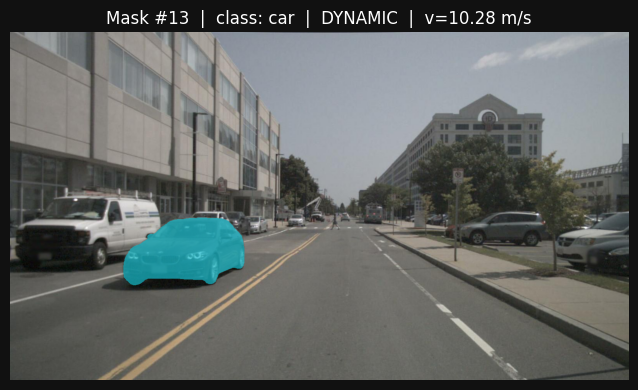

,rel_idx,method,tx,ty,yaw_deg,fitness,rmse
0,-10,icp,-5.328,0.008,0.0,1.0000,0.0199
1,-9,centroid,-4.612,-0.620,0.0,NaN,NaN
2,-8,empty,0.000,0.000,0.0,NaN,NaN
3,-7,icp,-3.691,0.003,0.0,1.0000,0.0407
4,-6,icp,-3.024,0.121,0.0,1.0000,0.0460
5,-5,icp,-2.363,0.014,0.0,1.0000,0.0599
6,-4,no_cluster,0.000,0.000,0.0,NaN,NaN
7,-3,icp,-1.280,-0.069,0.0,1.0000,0.0763
8,-2,icp,-0.965,-0.105,0.0,1.0000,0.1021
9,-1,icp,-0.492,-0.068,0.0,1.0000,0.1101


In [453]:
import pandas as pd
from plotly.subplots import make_subplots

assert 0 <= MASK_IDX < len(mask_results), \
    f'MASK_IDX={MASK_IDX} out of range [0, {len(mask_results)-1}]'
_mr     = mask_results[MASK_IDX]
_status = 'DYNAMIC' if _mr['is_dynamic'] else 'static'
_title  = (f'Mask #{MASK_IDX}  |  class: {_mr["prompt"]}  |  '
           f'{_status}  |  v={_mr["velocity_mps"]:.2f} m/s')

# ── 10a: Mask overlay on anchor image ─────────────────────────────────────────
_ov  = img_rgb.copy()
_m2d = sam3_masks[MASK_IDX]['binary_mask']
_cr  = MASK_COLORS(MASK_IDX)
_col = np.array([int(_cr[0]*255), int(_cr[1]*255), int(_cr[2]*255)])
_ov[_m2d] = (_ov[_m2d] * 0.3 + _col * 0.7).astype(np.uint8)

_fig_ov, _ax_ov = plt.subplots(figsize=(14, 4), facecolor='#111111')
_ax_ov.imshow(_ov)
_ax_ov.axis('off')
_ax_ov.set_title(_title, color='white', fontsize=12)
_fig_ov.patch.set_facecolor('#111111')
plt.tight_layout(); plt.show()

# ── 10b: Side-by-side 3D: HDBSCAN clusters (raw) vs ICP-compensated ───────────
# Left  = per-sweep HDBSCAN clusters, uncompensated  → smearing visible
# Right = same clusters after SE(2) ICP → should collapse to one surface
_cmap3 = plt.colormaps.get_cmap('cool').resampled(len(sweep_data))

def _sw_rgb(i):
    c = _cmap3(i)
    return f'rgb({int(c[0]*255)},{int(c[1]*255)},{int(c[2]*255)})'

_fig3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=['HDBSCAN clusters — raw (smearing visible)',
                    'SE(2) ICP-compensated'],
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    horizontal_spacing=0.02,
)

for _i, _s in enumerate(sweep_data):
    _col3  = _sw_rgb(_i)
    _sw_lb = ('anchor' if _s['rel_idx'] == 0
              else f'sw{_s["rel_idx"]:+d} ({_s["dt_ms"]:+.0f} ms)')

    _raw = _mr['per_sweep_pts'][_i]
    if _raw is not None and len(_raw) > 0:
        _fig3.add_trace(go.Scatter3d(
            x=_raw[:, 0], y=_raw[:, 1], z=_raw[:, 2], mode='markers',
            marker=dict(size=2.5, color=_col3, opacity=0.85),
            name=_sw_lb, legendgroup=_sw_lb, showlegend=True,
        ), row=1, col=1)

    _comp = _mr['pts_comp_per_sw'][_i]
    if _comp is not None and len(_comp) > 0:
        _fig3.add_trace(go.Scatter3d(
            x=_comp[:, 0], y=_comp[:, 1], z=_comp[:, 2], mode='markers',
            marker=dict(size=2.5, color=_col3, opacity=0.85),
            name=_sw_lb, legendgroup=_sw_lb, showlegend=False,
        ), row=1, col=2)

_sc = dict(
    xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
    aspectmode='data', bgcolor='rgb(15,15,25)',
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    zaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
)
_fig3.update_layout(
    title=_title, scene=_sc, scene2=_sc,
    scene_camera=dict(up=dict(x=0, y=0, z=1)),
    scene2_camera=dict(up=dict(x=0, y=0, z=1)),
    paper_bgcolor='rgb(15,15,25)', font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.5)', font=dict(size=10)),
    width=1200, height=560, margin=dict(l=0, r=0, t=55, b=0),
    uirevision='shared',
)
_fig3.show()

# ── 10c: Per-sweep ICP table ──────────────────────────────────────────────────
_df = pd.DataFrame(_mr['icp_records'])
for _cn in ['tx', 'ty', 'yaw_deg']:
    _df[_cn] = _df[_cn].round(3)
for _cn in ['fitness', 'rmse']:
    _df[_cn] = _df[_cn].round(4)
display(_df[['rel_idx', 'method', 'tx', 'ty', 'yaw_deg', 'fitness', 'rmse']])

# ── 10d: Overlay — grey=raw aggregated (all in-mask pts, no HDBSCAN/ICP)
#                   color=ICP-compensated clusters (per-sweep, colour by sweep)
# Use this to judge whether the ICP alignment and orientation arrow make sense
# relative to the full unfiltered point cloud context.
_fig_ov3 = go.Figure()

# Grey background: all raw in-mask points from every sweep (before any filtering)
_raw_all_parts = [p for p in _mr['per_sweep_pts_mask'] if p is not None and len(p) > 0]
_raw_all = (
    np.concatenate(_raw_all_parts, axis=0)
    if _raw_all_parts else np.empty((0, 3), np.float32)
)
if len(_raw_all) > 0:
    _fig_ov3.add_trace(go.Scatter3d(
        x=_raw_all[:, 0], y=_raw_all[:, 1], z=_raw_all[:, 2],
        mode='markers',
        marker=dict(size=1.5, color='rgba(180,180,180,0.18)'),
        name='raw in-mask (all sweeps)',
        showlegend=True,
    ))

# Coloured: ICP-compensated per-sweep clusters
for _i, _s in enumerate(sweep_data):
    _comp = _mr['pts_comp_per_sw'][_i]
    if _comp is None or len(_comp) == 0:
        continue
    _col3  = _sw_rgb(_i)
    _sw_lb = ('anchor' if _s['rel_idx'] == 0
              else f'sw{_s["rel_idx"]:+d} ({_s["dt_ms"]:+.0f} ms)')
    _fig_ov3.add_trace(go.Scatter3d(
        x=_comp[:, 0], y=_comp[:, 1], z=_comp[:, 2],
        mode='markers',
        marker=dict(size=2.5, color=_col3, opacity=0.90),
        name=_sw_lb,
        legendgroup=_sw_lb,
    ))

# Orientation arrow (same as §12)
_final = _mr['pts_comp_all']
if len(_final) > 0:
    _cx = float(_final[:, 0].mean())
    _cy = float(_final[:, 1].mean())
    _cz = float(_final[:, 2].mean())
    _hdg = _mr['heading_rad']
    if not np.isnan(_hdg):
        _ARROW = 2.5
        _dx = float(np.cos(_hdg)) * _ARROW
        _dy = float(np.sin(_hdg)) * _ARROW
        _tx, _ty, _tz = _cx + _dx, _cy + _dy, _cz
        _arrow_color = f'rgb({int(_cr[0]*255)},{int(_cr[1]*255)},{int(_cr[2]*255)})'
        _fig_ov3.add_trace(go.Scatter3d(
            x=[_cx, _tx], y=[_cy, _ty], z=[_cz, _tz],
            mode='lines', line=dict(color=_arrow_color, width=6),
            name='orientation', showlegend=True,
        ))
        _fig_ov3.add_trace(go.Cone(
            x=[_tx], y=[_ty], z=[_tz],
            u=[float(np.cos(_hdg))], v=[float(np.sin(_hdg))], w=[0.0],
            sizemode='absolute', sizeref=0.7,
            colorscale=[[0, _arrow_color], [1, _arrow_color]],
            showscale=False, showlegend=False,
        ))
        _hdg_s = 'motion' if _mr['is_dynamic'] else 'PCA'
        _vel   = _mr['velocity_mps']
        _vtxt  = f'{_vel:.1f} m/s' if _mr['is_dynamic'] else f'{np.degrees(_hdg):.0f} deg ({_hdg_s})'
        _fig_ov3.add_trace(go.Scatter3d(
            x=[_tx], y=[_ty], z=[_tz + 0.35],
            mode='text', text=[_vtxt],
            textfont=dict(color=_arrow_color, size=13),
            showlegend=False,
        ))

_fig_ov3.update_layout(
    title=(f'Overlay: grey=raw in-mask, color=ICP-compensated  |  {_title}'),
    scene=dict(
        xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
        aspectmode='data', bgcolor='rgb(15,15,25)',
        xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
        yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
        zaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    ),
    paper_bgcolor='rgb(15,15,25)', font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.5)', font=dict(size=10)),
    width=1100, height=620, margin=dict(l=0, r=0, t=50, b=0),
)
_fig_ov3.show()


## 11. BEV Centroid Trails — Scene Overview

Scene-level sanity check:
- **Static objects** → single dot at their anchor-sweep centroid
- **Dynamic objects** → line segments connecting per-sweep centroids + arrow at the tip

Each object is labelled with its mask index, class, and motion tag.

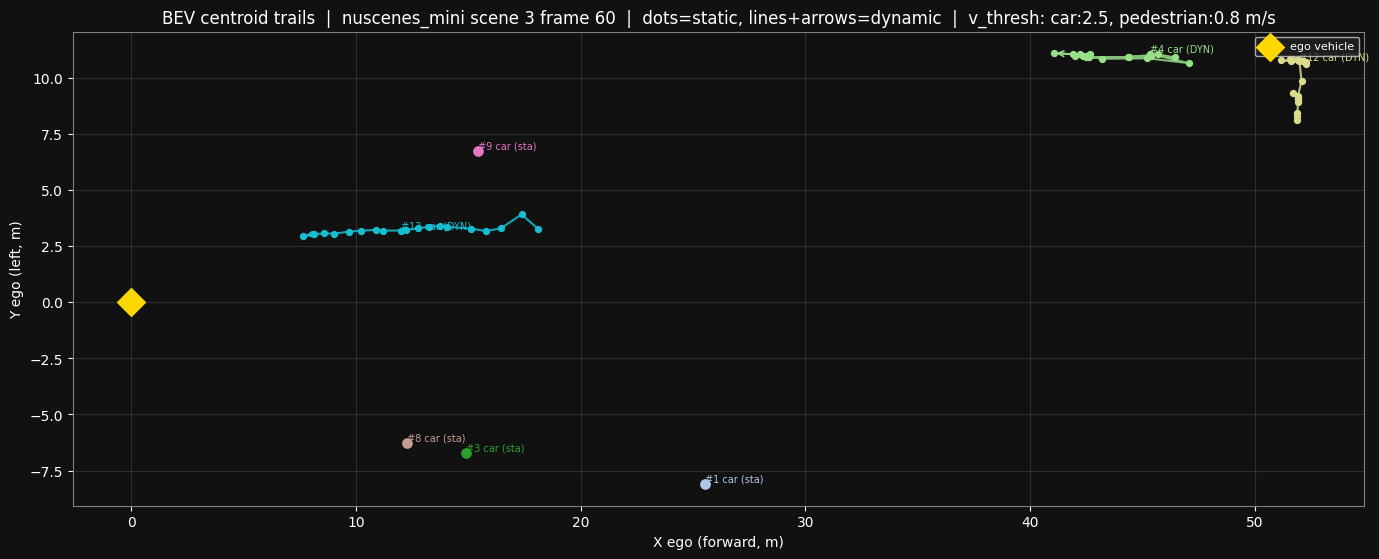

In [454]:
_anchor_sw_i_bev = next(i for i, s in enumerate(sweep_data) if s['rel_idx'] == 0)

_fig_bev, _ax_bev = plt.subplots(figsize=(14, 8), facecolor='#111111')
_ax_bev.set_facecolor('#111111')

for _mr in mask_results:
    _cr     = MASK_COLORS(_mr['mask_idx'])
    _color  = _cr[:3]
    _cents  = _mr['per_sweep_cents']
    _valid  = [(i, c) for i, c in enumerate(_cents) if c is not None]
    if not _valid:
        continue

    _xs = [c[0] for _, c in _valid]
    _ys = [c[1] for _, c in _valid]
    _lbl = f'#{_mr["mask_idx"]} {_mr["prompt"]} ({"DYN" if _mr["is_dynamic"] else "sta"})'

    if _mr['is_dynamic']:
        _ax_bev.plot(_xs, _ys, '-', color=_color, lw=1.5, alpha=0.85)
        _ax_bev.scatter(_xs, _ys, s=18, color=_color, zorder=5)
        if len(_xs) >= 2:
            _ax_bev.annotate('',
                xy=(_xs[-1], _ys[-1]), xytext=(_xs[-2], _ys[-2]),
                arrowprops=dict(arrowstyle='->', color=_color, lw=1.2))
        _li = _anchor_sw_i_bev if _anchor_sw_i_bev < len(_xs) else 0
        _ax_bev.text(_xs[_li], _ys[_li], _lbl,
                     color=_color, fontsize=7, ha='left', va='bottom')
    else:
        _anc_c = _cents[_anchor_sw_i_bev]
        _px, _py = (_anc_c[0], _anc_c[1]) if _anc_c is not None else (_xs[0], _ys[0])
        _ax_bev.scatter([_px], [_py], s=45, color=_color, marker='o', zorder=5)
        _ax_bev.text(_px, _py, _lbl, color=_color, fontsize=7, ha='left', va='bottom')

_ax_bev.scatter([0], [0], s=200, c='gold', marker='D', zorder=10, label='ego vehicle')
_ax_bev.set_aspect('equal')
_ax_bev.set_xlabel('X ego (forward, m)', color='white')
_ax_bev.set_ylabel('Y ego (left, m)',     color='white')
_ax_bev.tick_params(colors='white')
for _sp in _ax_bev.spines.values():
    _sp.set_color('gray')

# Per-class thresholds (replaces the removed global DYNAMIC_THRESH_MPS)
_thr_summary = ', '.join(
    f'{p}:{t:.1f}' for p, t in sorted(
        {r['prompt']: r['dynamic_thresh_mps'] for r in mask_results}.items()
    )
)
_ax_bev.set_title(
    f'BEV centroid trails  |  {DATASET} scene {SCENE_IDX} frame {FRAME_IDX}  '
    f'|  dots=static, lines+arrows=dynamic  |  v_thresh: {_thr_summary} m/s',
    color='white',
)
_ax_bev.legend(loc='upper right', facecolor='#222222', labelcolor='white', fontsize=8)
_ax_bev.grid(True, alpha=0.12, color='white')
plt.tight_layout()
plt.show()


## 12. Final Cluster + Orientation Visualiser

3D Plotly view of the **final HDBSCAN result** per mask:

- **Coloured points** — `pts_comp_all`: the final cluster that survived HDBSCAN (passed to SAM3D)
- **Grey points** — pre-final-HDBSCAN cloud: for dynamic objects this is the ICP-compensated per-sweep concatenation; for static it is the raw aggregated in-mask points
- **Arrow** — orientation: motion heading for dynamic, PCA structural axis for static
- **Label** — velocity in m/s next to the arrow tip

Set `FINAL_VIZ_MASK = None` to show all masks together, or an integer to inspect one.


In [455]:
FINAL_VIZ_MASK = MASK_IDX   # uses the same selection as §10; set to an int to override
ARROW_LEN_M    = 2.5         # orientation arrow length in metres

_masks_to_show = (
    mask_results if FINAL_VIZ_MASK is None
    else [mask_results[FINAL_VIZ_MASK]]
)

_fig_fin = go.Figure()

for _mr in _masks_to_show:
    _mi    = _mr['mask_idx']
    _cr    = MASK_COLORS(_mi)
    _color = f'rgb({int(_cr[0]*255)},{int(_cr[1]*255)},{int(_cr[2]*255)})'
    _tag   = 'DYN' if _mr['is_dynamic'] else 'sta'
    _lbl   = f'#{_mi} {_mr["prompt"]} ({_tag})'

    # ── Pre-final-HDBSCAN cloud (grey background) ─────────────────────────────
    # Dynamic: ICP-compensated per-sweep clusters concatenated (before final HDBSCAN)
    # Static:  raw in-mask points from all sweeps (before HDBSCAN)
    if _mr['is_dynamic']:
        _pre_parts = [c for c in _mr['pts_comp_per_sw']
                      if c is not None and len(c) > 0]
    else:
        _pre_parts = [p for p in _mr['per_sweep_pts_mask']
                      if p is not None and len(p) > 0]

    _pre_cat = (
        np.concatenate(_pre_parts, axis=0)
        if _pre_parts else np.empty((0, 3), np.float32)
    )
    _grey = _pre_cat

    if len(_grey) > 0:
        _fig_fin.add_trace(go.Scatter3d(
            x=_grey[:, 0], y=_grey[:, 1], z=_grey[:, 2],
            mode='markers',
            marker=dict(size=1.5, color='rgba(160,160,160,0.20)'),
            name=f'{_lbl} — pre-HDBSCAN',
            legendgroup=f'mask_{_mi}',
            showlegend=False,
        ))

    # ── Final cluster (coloured) ──────────────────────────────────────────────
    _final = _mr['pts_comp_all']
    if len(_final) == 0:
        continue

    _cx = float(_final[:, 0].mean())
    _cy = float(_final[:, 1].mean())
    _cz = float(_final[:, 2].mean())

    _fig_fin.add_trace(go.Scatter3d(
        x=_final[:, 0], y=_final[:, 1], z=_final[:, 2],
        mode='markers',
        marker=dict(size=2.5, color=_color, opacity=0.90),
        name=_lbl,
        legendgroup=f'mask_{_mi}',
    ))

    # ── Orientation arrow ─────────────────────────────────────────────────────
    _hdg = _mr['heading_rad']
    if np.isnan(_hdg):
        continue

    _dx   = float(np.cos(_hdg)) * ARROW_LEN_M
    _dy   = float(np.sin(_hdg)) * ARROW_LEN_M
    _tx   = _cx + _dx
    _ty   = _cy + _dy
    _tz   = _cz

    # Arrow shaft
    _fig_fin.add_trace(go.Scatter3d(
        x=[_cx, _tx], y=[_cy, _ty], z=[_cz, _tz],
        mode='lines',
        line=dict(color=_color, width=5),
        legendgroup=f'mask_{_mi}',
        showlegend=False,
    ))

    # Arrowhead cone
    _fig_fin.add_trace(go.Cone(
        x=[_tx], y=[_ty], z=[_tz],
        u=[float(np.cos(_hdg))],
        v=[float(np.sin(_hdg))],
        w=[0.0],
        sizemode='absolute', sizeref=0.7,
        colorscale=[[0, _color], [1, _color]],
        showscale=False,
        legendgroup=f'mask_{_mi}',
        showlegend=False,
    ))

    # Velocity + heading label at arrow tip
    _vel   = _mr['velocity_mps']
    _hdg_s = 'motion' if _mr['is_dynamic'] else 'PCA'
    _vtxt  = f'{_vel:.1f} m/s' if _mr['is_dynamic'] else f'{np.degrees(_hdg):.0f} deg ({_hdg_s})'
    _fig_fin.add_trace(go.Scatter3d(
        x=[_tx], y=[_ty], z=[_tz + 0.35],
        mode='text',
        text=[_vtxt],
        textfont=dict(color=_color, size=12),
        legendgroup=f'mask_{_mi}',
        showlegend=False,
    ))

# Ego marker
_fig_fin.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers',
    marker=dict(size=8, color='gold', symbol='diamond'),
    name='ego',
))

_n_shown = len(_masks_to_show)
_title_fin = (
    f'Final HDBSCAN clusters + orientation  |  {DATASET} scene {SCENE_IDX} frame {FRAME_IDX}  '
    f'|  {_n_shown} mask(s)  |  arrow = orientation  |  coloured = final cluster  |  grey = pre-HDBSCAN'
)

_scene_cfg = dict(
    xaxis_title='X ego (forward, m)',
    yaxis_title='Y ego (left, m)',
    zaxis_title='Z ego (up, m)',
    aspectmode='data',
    bgcolor='rgb(15,15,25)',
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
    zaxis=dict(gridcolor='rgba(255,255,255,0.08)', color='white'),
)

_fig_fin.update_layout(
    title=_title_fin,
    scene=_scene_cfg,
    paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.55)', font=dict(size=10)),
    width=1150, height=680,
    margin=dict(l=0, r=0, t=50, b=0),
)
_fig_fin.show()
